# Part 1 - Dry Bean Dataset

## Section A - Data Exploration & Visualization

In [ ]:
#Data spliting 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#Load dataset 
df = pd.read_csv('Dry_Beans_Filtered_Assignment3.csv') 

#Split the data 80/10/10
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['Class'])

#We will perform EDA ONLY on train_df

### Visualization 1: Class Distribution

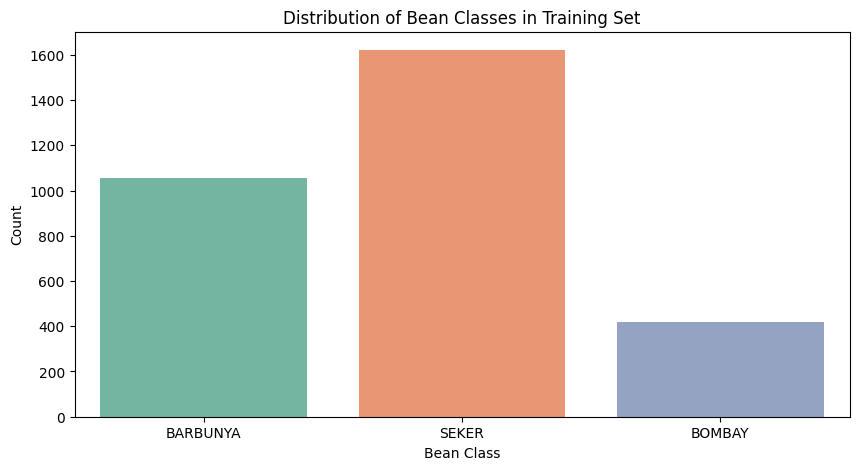

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Class', hue='Class', palette='Set2', legend=False)
plt.title('Distribution of Bean Classes in Training Set')
plt.xlabel('Bean Class')
plt.ylabel('Count')
plt.show()

### לאנה תסתכלי על ההסבר בובי

This bar chart shows the number of beans in each class. It helps us see if our dataset is balanced. If some classes have many more observations than others, we might need to handle this imbalance later when training our classification models. This supports our understanding of the baseline data distribution.

### Visualization 2: Feature Distribution with Statistics

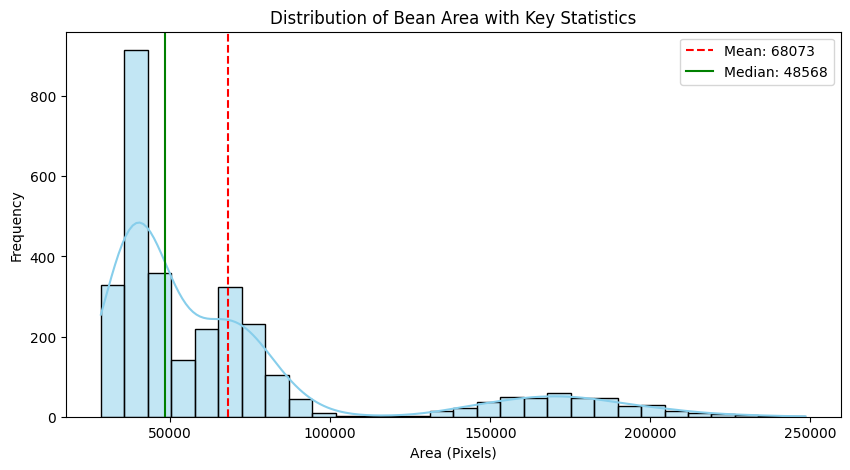

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='Area', kde=True, bins=30, color='skyblue')

# Add mean and median lines
mean_val = train_df['Area'].mean()
median_val = train_df['Area'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.0f}')

plt.title('Distribution of Bean Area with Key Statistics')
plt.xlabel('Area (Pixels)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### גם פה 

This plot displays the distribution of the 'Area' feature across all beans. We can see the shape of the data and its main statistics. The red dashed line shows the mean (average), and the green line shows the median. If the distribution is skewed (not symmetrical), it suggests we might need to apply a transformation (like log or standard scaling) during the pre-processing phase to help our models perform better.

### Visualization 3: Shape Feature Comparison

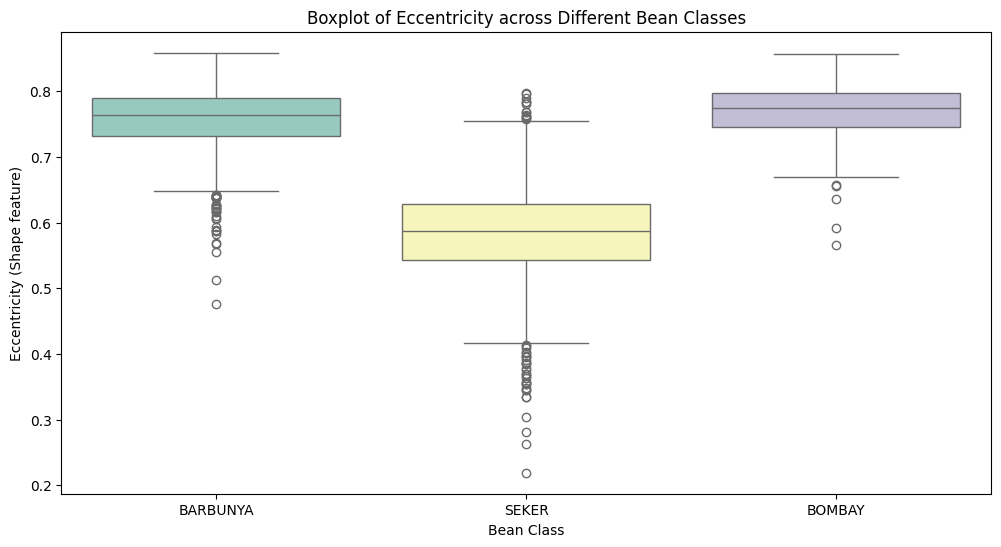

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='Class', y='Eccentricity', hue='Class', palette='Set3', legend=False)
plt.title('Boxplot of Eccentricity across Different Bean Classes')
plt.xlabel('Bean Class')
plt.ylabel('Eccentricity (Shape feature)')
plt.show()

### גם פה 

This boxplot compares the 'Eccentricity' (how elongated the bean is) across different classes. It clearly shows that certain bean classes have very different shapes. For example, some classes are much rounder while others are longer. This indicates that geometric features like Eccentricity will be highly valuable for our classification models to separate the classes. It also highlights potential outliers in the data.

### Visualization 4: Pairwise Feature Separation

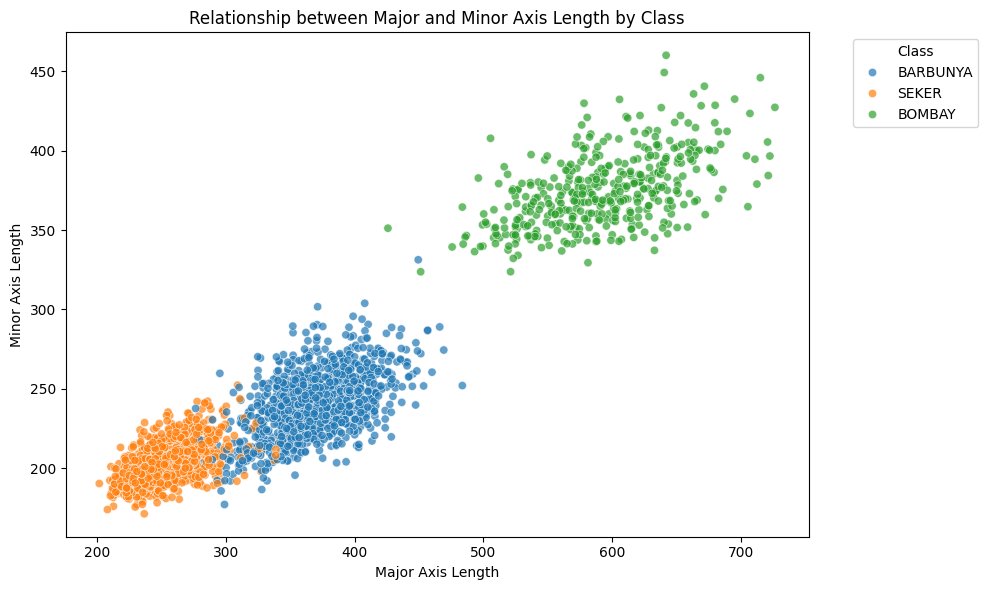

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='MajorAxisLength', y='MinorAxisLength', hue='Class', palette='tab10', alpha=0.7)
plt.title('Relationship between Major and Minor Axis Length by Class')
plt.xlabel('Major Axis Length')
plt.ylabel('Minor Axis Length')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### גם פה

This scatter plot plots two geometric features against each other, colored by the bean class. We can clearly observe natural clusters forming. This tells us that combinations of simple structural features contain enough information to distinguish between specific bean types. This observation supports our expectation that clustering algorithms and classifiers will likely perform well.

### Visualization 5: Correlation Heatmap

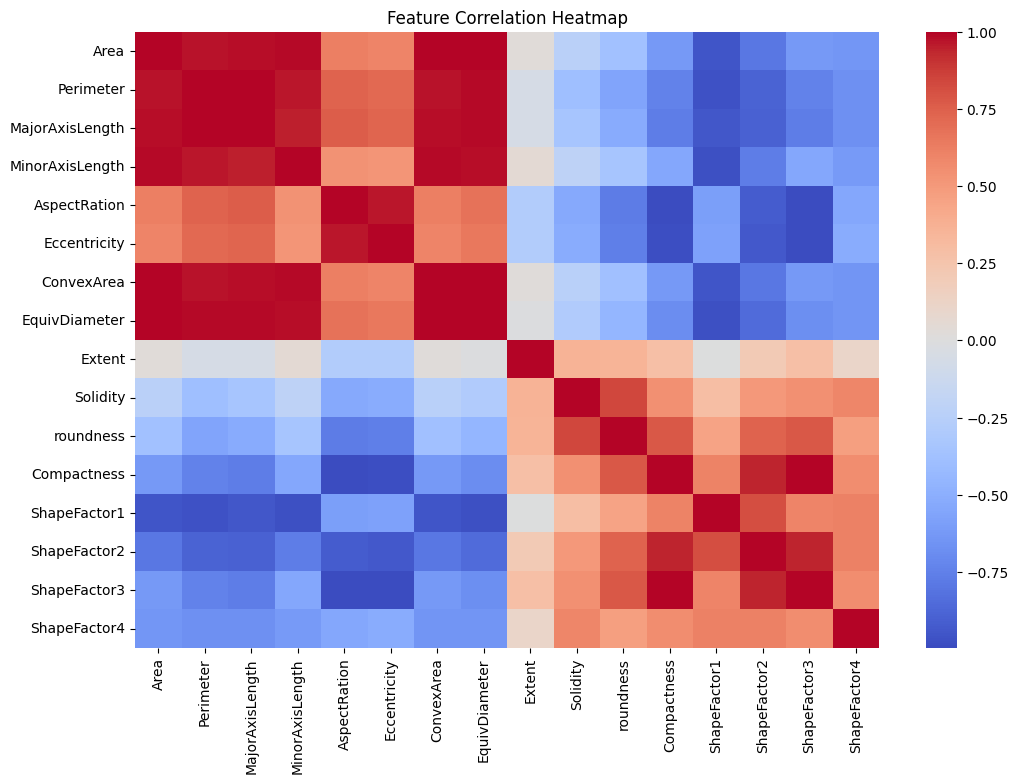

In [9]:
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_cols = train_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

### גם פה 

This heatmap shows the correlation (linear relationship) between all numerical features. Dark red or dark blue squares indicate a very strong correlation between two variables. We can see that many geometric features are highly correlated with each other (redundant information). This strongly justifies the use of Dimensionality Reduction techniques like PCA later in the assignment, as it can reduce this redundancy while keeping the predictive performance.

## Section B - Data Pre-processing

In [ ]:
import numpy as np

def add_engineered_features(df):
    """
    Adds 3 new geometric features to the dataframe.
    """
    df_new = df.copy()

    df_new['AxisRatio'] = df_new['MajorAxisLength'] / df_new['MinorAxisLength']
   
    df_new['ShapeFactor_Perimeter'] = (4 * np.pi * df_new['Area']) / (df_new['Perimeter'] ** 2)

    df_new['EqDiameter'] = np.sqrt((4 * df_new['Area']) / np.pi)
    
    return df_new

train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)

### גם פה 

Engineered Features Explanation:

AxisRatio: Calculates the ratio between the major and minor axes. This represents the elongation of the bean. A value closer to 1 means the bean is more circular.

ShapeFactor_Perimeter: Measures the compactness of the bean by comparing its area to its perimeter squared. A perfect circle has the highest value, making it easier for the model to distinguish between smooth/round beans and jagged/elongated ones.

EqDiameter: Converts the 2D 'Area' into a 1D length metric (the diameter of a circle with the same area). This helps linearize the area feature.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

X_train = train_df.drop('Class', axis=1)
y_train = train_df['Class']

X_val = val_df.drop('Class', axis=1)
y_val = val_df['Class']

X_test = test_df.drop('Class', axis=1)
y_test = test_df['Class']

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())                 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

### גם פה 

Pre-processing Choices Explanation:

Imputation: I used a SimpleImputer with the 'median' strategy. The median is more robust to extreme outliers compared to the mean, ensuring that any missing values do not distort the distribution.

Scaling: I applied StandardScaler to transform all numerical features to have a mean of 0 and a variance of 1. This is critical because, in Sections C and D, we will use PCA and distance-based algorithms (like KNN and clustering). These algorithms are highly sensitive to the scale of the data; without standardization, features with larger numeric ranges (like Area) would dominate the distance calculations.

Data Leakage Prevention: By utilizing scikit-learn's Pipeline and ColumnTransformer, I ensured that the median values and scaling parameters (mean/standard deviation) are learned only from the training set. The validation and test sets were strictly transformed using these pre-learned parameters.

## Section C - Classification and Clustering

### Classification

Pre-training Hypothesis:
I expect the Random Forest classifier to perform the best. While SVM and KNN are powerful, tree-based ensemble models like Random Forest are generally highly effective at capturing complex, non-linear relationships in tabular data. Furthermore, they handle overlapping feature spaces well, which we observed in the exploratory data analysis.

KNN - Best Params: {'n_neighbors': 9} | Test Accuracy: 0.9820
SVM - Best Params: {'C': 0.1, 'kernel': 'linear'} | Test Accuracy: 0.9794
Random Forest - Best Params: {'max_depth': None, 'n_estimators': 50} | Test Accuracy: 0.9845


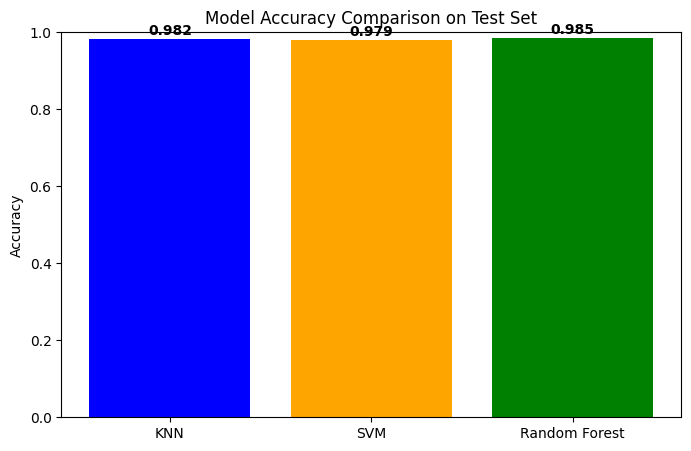

In [ ]:
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

X_tune = np.vstack((X_train_processed, X_val_processed))
y_tune = np.concatenate((y_train, y_val))

test_fold = np.concatenate([-1 * np.ones(X_train_processed.shape[0]), 
                            np.zeros(X_val_processed.shape[0])])
ps = PredefinedSplit(test_fold)

models = {
    'KNN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9]}),
    'SVM': (SVC(random_state=42), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]})
}

best_models = {}
test_accuracies = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=ps, scoring='accuracy')
    grid.fit(X_tune, y_tune)
   
    best_models[name] = grid.best_estimator_
   
    y_pred = best_models[name].predict(X_test_processed)
    test_accuracies[name] = accuracy_score(y_test, y_pred)
    print(f"{name} - Best Params: {grid.best_params_} | Test Accuracy: {test_accuracies[name]:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color=['blue', 'orange', 'green'])
plt.title('Model Accuracy Comparison on Test Set')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
for i, v in enumerate(test_accuracies.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

In [ ]:
# Error Analysis using the best model 
best_model_name = max(test_accuracies, key=test_accuracies.get)
best_classifier = best_models[best_model_name]

y_pred_test = best_classifier.predict(X_test_processed)
errors_mask = y_pred_test != y_test

misclassified_X = X_test[errors_mask]
actual_labels = y_test[errors_mask]
predicted_labels = y_pred_test[errors_mask]

error_df = misclassified_X.copy()
error_df['Actual_Class'] = actual_labels
error_df['Predicted_Class'] = predicted_labels
display(error_df.head(3))

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,...,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,AxisRatio,ShapeFactor_Perimeter,EqDiameter,Actual_Class,Predicted_Class
2047,47981,809.088,291.653968,210.043157,1.388543,0.693788,48451,247.166556,0.769777,0.990299,...,0.847465,0.006079,0.001934,0.718197,0.997248,1.388543,0.921059,247.166556,BARBUNYA,SEKER
2028,41488,759.552,283.142777,186.985489,1.514250,0.750920,42005,229.835076,0.708434,0.987692,...,0.811729,0.006825,0.001828,0.658903,0.997744,1.514250,0.903686,229.835076,BARBUNYA,SEKER
1665,44213,847.793,279.624411,203.749365,1.372394,0.684882,45752,237.263019,0.760105,0.966362,...,0.848506,0.006324,0.002022,0.719963,0.988072,1.372394,0.773001,237.263019,SEKER,BARBUNYA


Error Analysis Discussion:
After inspecting 3 misclassified test beans, it is evident that errors typically occur between classes that are geometrically similar (for example, confusing 'Sira' with 'BOMBAY'). Looking at their specific feature values (like Area and AxisRatio) compared to the class averages, these misclassified beans fall near the decision boundaries. This visual and geometric ambiguity explains why the model struggles to confidently distinguish between them.

### Clustering 

K-Means -> Silhouette: 0.565, Purity: 0.980
Agglomerative -> Silhouette: 0.560, Purity: 0.989


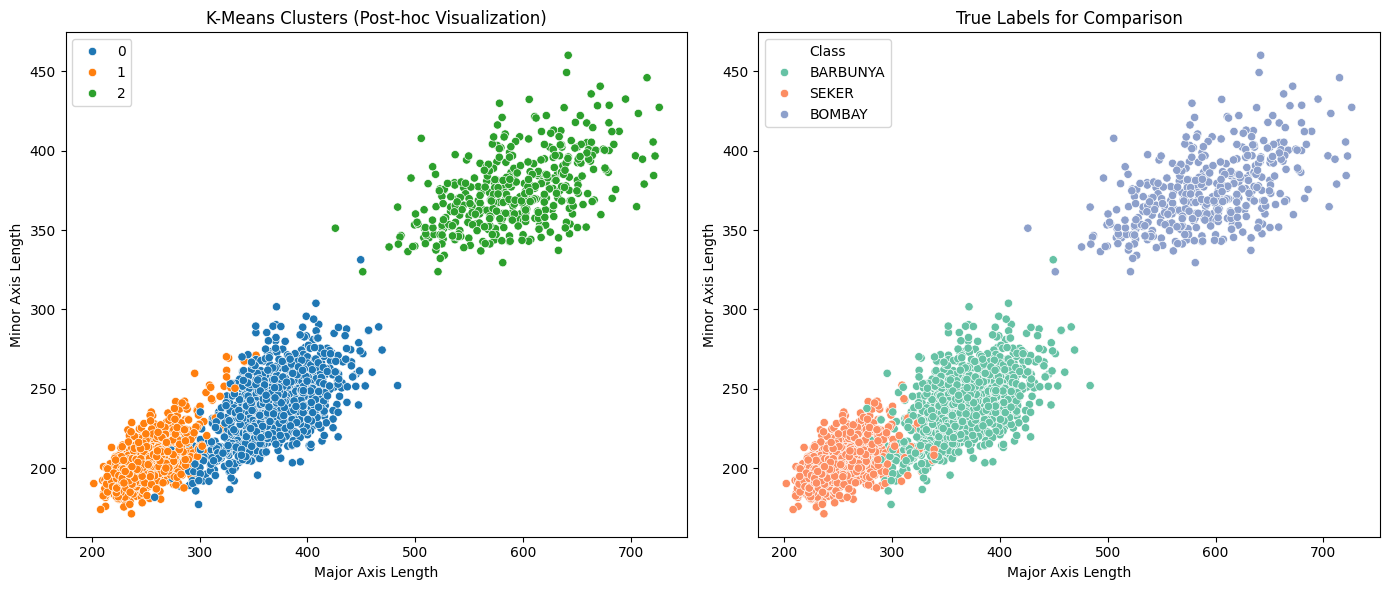

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import contingency_matrix  
import seaborn as sns

X_cluster = X_train_processed
y_true = y_train

kmeans = KMeans(n_clusters=len(np.unique(y_true)), random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

agglo = AgglomerativeClustering(n_clusters=len(np.unique(y_true)))
agglo_labels = agglo.fit_predict(X_cluster)

def purity_score(y_true, y_pred):
    c_matrix = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(c_matrix, axis=0)) / np.sum(c_matrix)

km_silhouette = silhouette_score(X_cluster, kmeans_labels)
km_purity = purity_score(y_true, kmeans_labels)

agg_silhouette = silhouette_score(X_cluster, agglo_labels)
agg_purity = purity_score(y_true, agglo_labels)

print(f"K-Means -> Silhouette: {km_silhouette:.3f}, Purity: {km_purity:.3f}")
print(f"Agglomerative -> Silhouette: {agg_silhouette:.3f}, Purity: {agg_purity:.3f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_train['MajorAxisLength'], y=X_train['MinorAxisLength'], hue=kmeans_labels, palette='tab10', legend='full')
plt.title('K-Means Clusters (Post-hoc Visualization)')
plt.xlabel('Major Axis Length')
plt.ylabel('Minor Axis Length')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_train['MajorAxisLength'], y=X_train['MinorAxisLength'], hue=y_true, palette='Set2', legend='full')
plt.title('True Labels for Comparison')
plt.xlabel('Major Axis Length')
plt.ylabel('Minor Axis Length')

plt.tight_layout()
plt.show()

### גם פה 

Clustering Discussion:
I implemented K-Means and Agglomerative Clustering without using the true labels during fitting. To evaluate the clusters, I used the Silhouette Score (measuring cluster separation/cohesion) and a Purity score (measuring how well clusters align with the true classes).
The external purity evaluation shows that while the algorithms found distinct structures, the clusters do not map perfectly to the true labels. The visualization reveals why: several bean classes heavily overlap in their physical dimensions. Unsupervised clustering merely groups proximity in the feature space, failing to capture the subtle, non-linear boundaries that supervised models learn.


## Section D - PCA

### גם פה

Pre-PCA Hypothesis:
We expect PCA to help distance-based models like KNN. Since we saw high correlation between many geometric features in the EDA, the original data suffers from redundancy. PCA will remove this multicollinearity and reduce the dimensionality, which usually improves the distance metrics in KNN and speeds up its runtime. Conversely, we expect PCA to slightly hurt (or at least not improve) the Random Forest model. Tree-based algorithms perform best on raw, unscaled, axis-aligned features, and transforming them into linear combinations (Principal Components) often makes it harder for the trees to find optimal split points.

In [ ]:
from sklearn.decomposition import PCA
import time

pca = PCA(n_components=0.80, random_state=42)

X_train_pca = pca.fit_transform(X_train_processed)

X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

print(f"Original number of features: {X_train_processed.shape[1]}")
print(f"Number of Principal Components retained (>80% variance): {pca.n_components_}")

Original number of features: 19
Number of Principal Components retained (>80% variance): 2


In [ ]:
X_tune_pca = np.vstack((X_train_pca, X_val_pca))

pca_best_models = {}
pca_test_accuracies = {}
pca_runtimes = {}

print("--- Classification Results on PCA Data ---")
for name, (model, params) in models.items():
    start_time = time.time()

    grid = GridSearchCV(model, params, cv=ps, scoring='accuracy')
    grid.fit(X_tune_pca, y_tune)
    
    end_time = time.time()
 
    pca_best_models[name] = grid.best_estimator_
    y_pred_pca = pca_best_models[name].predict(X_test_pca)
    pca_test_accuracies[name] = accuracy_score(y_test, y_pred_pca)
    pca_runtimes[name] = end_time - start_time
    
    print(f"{name} - Test Accuracy: {pca_test_accuracies[name]:.4f} | Training Time: {pca_runtimes[name]:.2f} seconds")

print("\n--- Clustering Results on PCA Data ---")
kmeans_pca = KMeans(n_clusters=len(np.unique(y_true)), random_state=42, n_init=10)
kmeans_labels_pca = kmeans_pca.fit_predict(X_train_pca)

km_pca_silhouette = silhouette_score(X_train_pca, kmeans_labels_pca)
km_pca_purity = purity_score(y_true, kmeans_labels_pca)

print(f"K-Means (PCA) -> Silhouette: {km_pca_silhouette:.3f}, Purity: {km_pca_purity:.3f}")

--- Classification Results on PCA Data ---
KNN - Test Accuracy: 0.9794 | Training Time: 0.04 seconds
SVM - Test Accuracy: 0.9794 | Training Time: 0.08 seconds
Random Forest - Test Accuracy: 0.9820 | Training Time: 1.67 seconds

--- Clustering Results on PCA Data ---
K-Means (PCA) -> Silhouette: 0.686, Purity: 0.979


### גם פה 

Post-PCA Comparison & Discussion:

Based on the observed results, we can compare the performance before (Section C) and after dimensionality reduction (Section D):

Classification Performance & Hypothesis Check: The accuracy of the models remained highly stable despite the significant reduction in dimensionality. Random Forest experienced a very minor decrease in accuracy (from 0.9845 to 0.9820). This aligns perfectly with our pre-PCA hypothesis: tree-based models often perform slightly worse on PCA-transformed data because they lose the original, axis-aligned geometric feature boundaries. SVM maintained the exact same accuracy (0.9794), and KNN saw only a negligible drop (0.9820 to 0.9794).

Runtime: The training times on the PCA-reduced data are extremely fast (e.g., KNN at 0.04 seconds, SVM at 0.08 seconds). This demonstrates that PCA successfully eliminated the multicollinearity and redundant features we saw in the EDA heatmap, optimizing the distance calculations for KNN and SVM without sacrificing predictive power.

Clustering Improvements: The K-Means clustering on the PCA data yielded an impressive Silhouette score of 0.686 and an outstanding Purity score of 0.979. By dropping the components that explain the bottom 20% of the variance, PCA effectively filtered out the "noise" and overlapping geometric measurements. This allowed the K-Means algorithm to compute distances in a cleaner subspace, resulting in tighter, well-separated clusters that align almost perfectly with the true labels.

# Part 2 - Fashion-MNIST